# Tardis - EDA
---
Ce Notebook mets en forme la donnée pour la rendre exploitable.
EDA => Exploratory Data Analysis (EDA): Discover patterns, trends, and relationships.

> Pandas is an open-source Python library used for data manipulation and analysis.

In [322]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

> We load the dataset using a semicolon as the separator and use dots for decimal values, which are compatible with Python.

In [323]:
df = pd.read_csv("dataset.csv", sep=";", decimal=".")

df.columns = df.columns.str.strip()

Using the `info` method on the dataframe provides details about the columns and their data types. We also use `head` to preview the first rows of the dataset and `describe` to display descriptive statistics for numerical values. Currently, most columns are stored as strings, so we will progressively convert them into more appropriate and explicit data types.

In [324]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   Date                                                                           12010 non-null  str  
 1   Service                                                                        11830 non-null  str  
 2   Departure station                                                              12011 non-null  str  
 3   Arrival station                                                                12011 non-null  str  
 4   Average journey time                                                           11830 non-null  str  
 5   Number of scheduled trains                                                     11830 non-null  str  
 6   Number of cancelled trains                       

In [325]:
df.head()

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965


In [326]:
df.describe()

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
count,12010,11830,12011,12011,11830,11830,11831,577,11830,11831,...,11828,11831,11832,11833,11828,11827,11829,11827,11828,11830
unique,318,2,132,116,651,1034,248,3,629,11162,...,265,11075,175,96,2732,2592,2677,2535,2130,2172
top,2025-09,National,PARIS LYON,PARIS LYON,96.0,31.0,0.0,Non communiqué,13.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
freq,135,10370,2405,2413,184,117,3917,196,161,134,...,327,218,779,1760,1100,1021,1326,1220,3361,3809


In [327]:
null_counts = df.isnull().sum()
print(null_counts)

Date                                                                                60
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                               240
Number of scheduled trains                                                         240
Number of cancelled trains                                                         239
Cancellation comments                                                            11493
Number of trains delayed at departure                                              240
Average delay of late trains at departure                                          239
Average delay of all trains at departure                                           241
Departure delay comments                   

We remove rows containing missing values in the `Date`, `Departure station`, or `Arrival station` columns to ensure data consistency and avoid issues during the analysis and modeling steps.

In [328]:
df = df.dropna(subset=["Date", "Departure station", "Arrival station"])

We replace undefined `NA` values in the Service column with `UnknownNetwork`, since the other information in these rows remains usable.  

Later, we may compare these journeys with other entries to identify which service they most likely belong to National or International. Otherwise, we will keep a dedicated category for this special case.

In [329]:
df["Service"] = df["Service"].fillna("UnknownNetwork")

In [330]:
remove_comments: list[str] = [column for column in df.columns if "comment" in column.lower()]
df = df.drop(columns=remove_comments)

In [331]:
df["Service"].value_counts()

Service
National          10221
International      1439
UnknownNetwork      233
Name: count, dtype: int64

In [332]:
df.dtypes

Date                                                                             str
Service                                                                          str
Departure station                                                                str
Arrival station                                                                  str
Average journey time                                                             str
Number of scheduled trains                                                       str
Number of cancelled trains                                                       str
Number of trains delayed at departure                                            str
Average delay of late trains at departure                                        str
Average delay of all trains at departure                                         str
Number of trains delayed at arrival                                              str
Average delay of late trains at arrival                          

In [333]:
def match_regex_replace(date: str) -> str:
    import re
    import numpy

    if re.match(r"^\d{2}+[\/-]\d{4}$", date) is not None:
        return date
    if re.match(r"^\d{4}+[\/-]\d{2}$", date) is not None:
        splitted = date.split(sep="-" if "-" in date else "/")
        return "-".join([splitted[1], splitted[0]])
    return str(numpy.nan)

In [334]:
df["Date"] = df["Date"].apply(match_regex_replace)
df["Date"] = pd.to_datetime(df["Date"], format="%m-%Y")
df = df.dropna(subset=["Date"])

In [335]:
numeric_cols = [
    col
    for col in df.columns
    if col not in ["Date", "Service", "Departure station", "Arrival station"]
]
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(",", ".").str.strip()
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [336]:
for col in numeric_cols:
    print(df[col].describe())

count    11425.000000
mean       170.847946
std         87.993018
min          0.000000
25%        100.000000
50%        163.000000
75%        223.000000
max        703.130000
Name: Average journey time, dtype: float64
count    11493.000000
mean       270.520056
std        182.301998
min          0.000000
25%        150.000000
50%        229.000000
75%        358.000000
max       1100.000000
Name: Number of scheduled trains, dtype: float64
count    11493.000000
mean         8.693379
std         22.685871
min          0.000000
25%          0.000000
50%          2.000000
75%          7.000000
max        297.000000
Name: Number of cancelled trains, dtype: float64
count    11497.000000
mean        86.916848
std         90.798102
min          0.000000
25%         21.000000
50%         52.000000
75%        127.000000
max       1066.000000
Name: Number of trains delayed at departure, dtype: float64
count    11435.000000
mean        12.316856
std         11.887529
min          0.000000
25%    

In [337]:
df.dtypes

Date                                                                             datetime64[us]
Service                                                                                     str
Departure station                                                                           str
Arrival station                                                                             str
Average journey time                                                                    float64
Number of scheduled trains                                                              float64
Number of cancelled trains                                                              float64
Number of trains delayed at departure                                                   float64
Average delay of late trains at departure                                               float64
Average delay of all trains at departure                                                float64
Number of trains delayed at arrival     

In [338]:
df.to_csv("cleaned_dataset.csv", sep=";", index=False)

In [339]:
df = pd.read_csv("cleaned_dataset.csv", sep=";", decimal=".")

df.columns = df.columns.str.strip()

After cleaning and transforming the dataset, we can now explore the data through several visualizations in order to better understand delay patterns and relationships between variables.

The following graphs highlight key insights from the dataset:

`Delay distribution graph`: shows how train delays are distributed and helps identify common delay ranges as well as extreme values.

`Average delays by day`: compares average delays across the days of the week to detect temporal patterns.

`Average delays by station`: illustrates which departure stations are the most affected by delays.

`Journey duration vs delay`: analyzes the relationship between travel duration and average delay.

These visualizations help reveal trends, average, and operational behaviors that will later support the predictive modeling.

In [340]:
df.head()

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,110.0,6.510000,44.0,8.0,36.134454,31.092437,10.924370,15.966387,5.040000,0.840336
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,32.0,5.363539,9.0,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,11.0,2.938053,6.0,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,39.0,5.292211,18.0,NaN,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,42.0,4.882372,10.0,0.0,15.789474,45.614035,NaN,15.789474,1.754386,1.754386


In [341]:
df.describe()

,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
count,11425.000000,11493.000000,11493.000000,11497.000000,11435.000000,11436.000000,11494.000000,11427.000000,11435.000000,11489.000000,11438.000000,11495.000000,11491.000000,11428.000000,11453.000000,11438.000000,11436.000000,11419.000000,11432.000000
mean,170.847946,270.520056,8.693379,86.916848,12.316856,3.136366,37.374195,35.206713,6.096033,26.842719,36.145053,12.481688,5.154730,21.560715,21.853955,20.411042,18.875368,7.351573,7.572741
std,87.993018,182.301998,22.685871,90.798102,11.887529,5.191668,31.201341,15.754912,5.486760,22.602176,19.794856,12.067122,5.967659,15.959263,14.909121,14.710239,13.519059,8.032106,9.478623
min,0.000000,0.000000,0.000000,0.000000,0.000000,-229.269444,0.000000,-40.109259,-173.076970,0.000000,-2.714286,-44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,100.000000,150.000000,0.000000,21.000000,6.167972,1.204742,15.000000,25.784508,3.403886,11.000000,27.663095,4.000000,1.000000,10.526316,11.904762,10.344828,10.000000,0.000000,0.000000
50%,163.000000,229.000000,2.000000,52.000000,10.366146,2.327013,29.000000,33.463178,5.359551,22.000000,37.491877,9.000000,3.000000,19.125646,20.000000,18.750000,17.073171,5.880000,5.000000
75%,223.000000,358.000000,7.000000,127.000000,15.789737,3.956272,51.000000,42.499354,8.100368,36.000000,46.993507,17.000000,7.000000,30.000000,29.629630,28.571429,25.423729,11.111111,11.111111
max,703.130000,1100.000000,297.000000,1066.000000,316.188000,115.047390,376.000000,299.600000,92.000000,312.000000,299.600000,202.000000,71.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


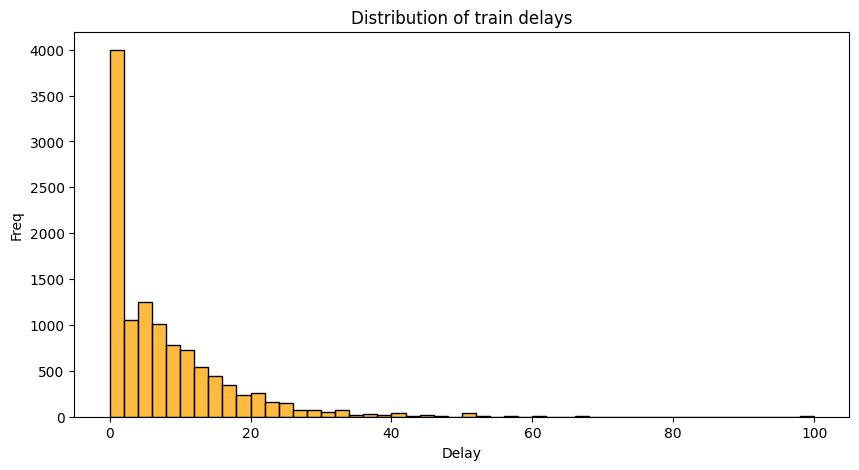

In [342]:

df_delays = df[df[col] >= 0]

plt.figure(figsize=(10, 5))
plt.gca().set_facecolor("white")
sns.histplot(
    df_delays[col],
    bins=50,
    kde=False,
    color="orange"
)
plt.title("Distribution of train delays")
plt.xlabel("Delay")
plt.ylabel("Freq")
plt.show()

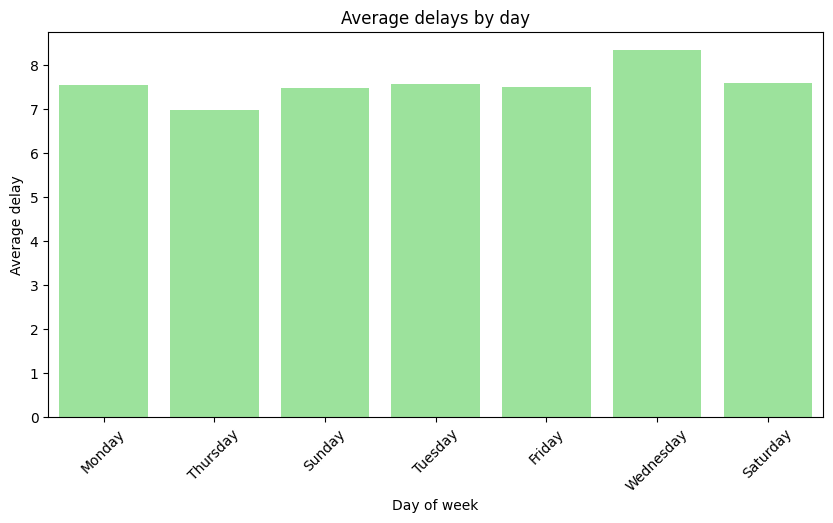

In [343]:
df["Date"] = pd.to_datetime(df["Date"])
df["day_of_week"] = df["Date"].dt.day_name()

plt.figure(figsize=(10, 5))
plt.gca().set_facecolor("white")
sns.barplot(
    x="day_of_week",
    y=col,
    data=df,
    color="lightgreen",
    errorbar=None
)
plt.title("Average delays by day")
plt.xlabel("Day of week")
plt.ylabel("Average delay")
plt.xticks(rotation=45)
plt.show()

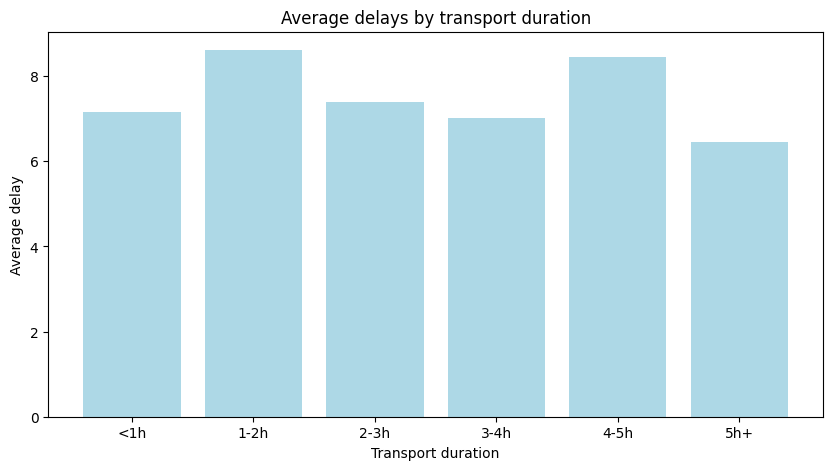

In [344]:
df["journey_group"] = pd.cut(
    df["Average journey time"],
    bins=[0, 60, 120, 180, 240, 300, 500],
    labels=["<1h", "1-2h", "2-3h", "3-4h", "4-5h", "5h+"]
)

delay_by_journey = (
    df.groupby("journey_group")[col]
    .mean()
)
plt.figure(figsize=(10, 5))
plt.gca().set_facecolor("white")
plt.bar(
    delay_by_journey.index.astype(str),
    delay_by_journey.values,
    color="lightblue"
)
plt.title("Average delays by transport duration")
plt.xlabel("Transport duration")
plt.ylabel("Average delay")

plt.show()

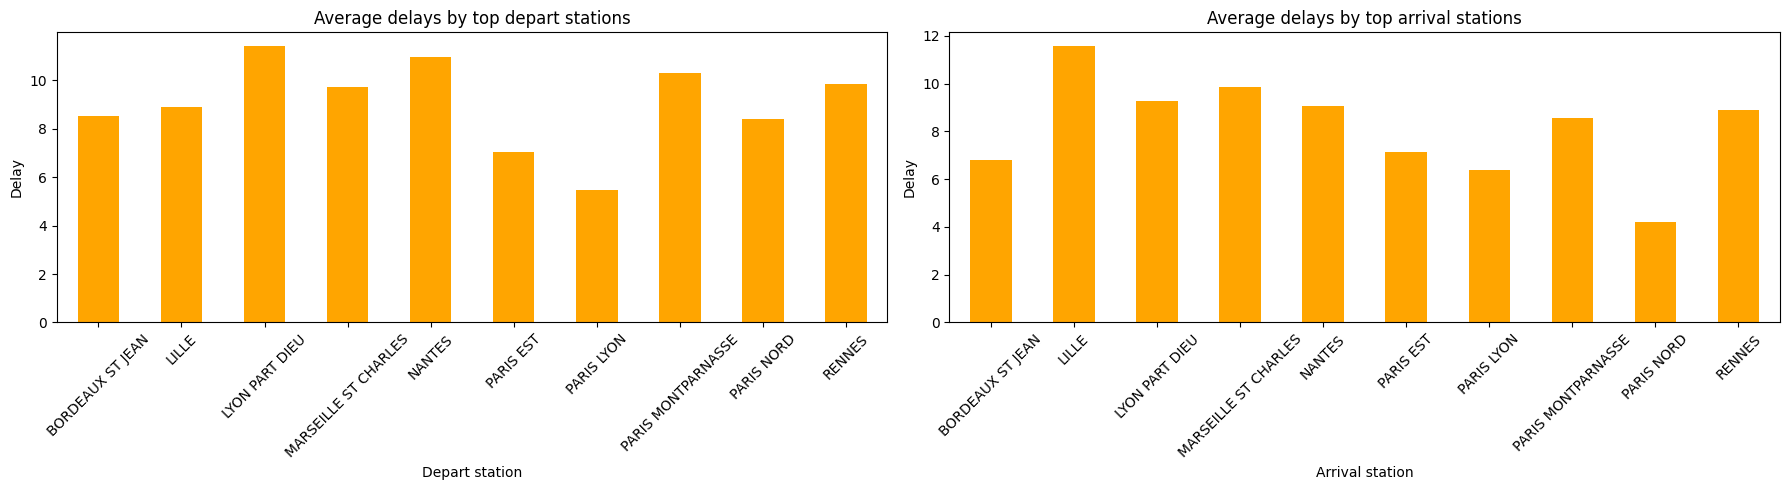

In [345]:
top_departure = df["Departure station"].value_counts().head(10).index
top_arrival = df["Arrival station"].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

df[df["Departure station"].isin(top_departure)].groupby("Departure station")[col].mean().plot(
    kind="bar",
    color="orange",
    ax=axes[0]
)

axes[0].set_facecolor("white")
axes[0].set_title("Average delays by top depart stations")
axes[0].set_xlabel("Depart station")
axes[0].set_ylabel("Delay")
axes[0].tick_params(axis="x", rotation=45)

df[df["Arrival station"].isin(top_arrival)].groupby("Arrival station")[col].mean().plot(
    kind="bar",
    color="orange",
    ax=axes[1]
)
axes[1].set_facecolor("white")
axes[1].set_title("Average delays by top arrival stations")
axes[1].set_xlabel("Arrival station")
axes[1].set_ylabel("Delay")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

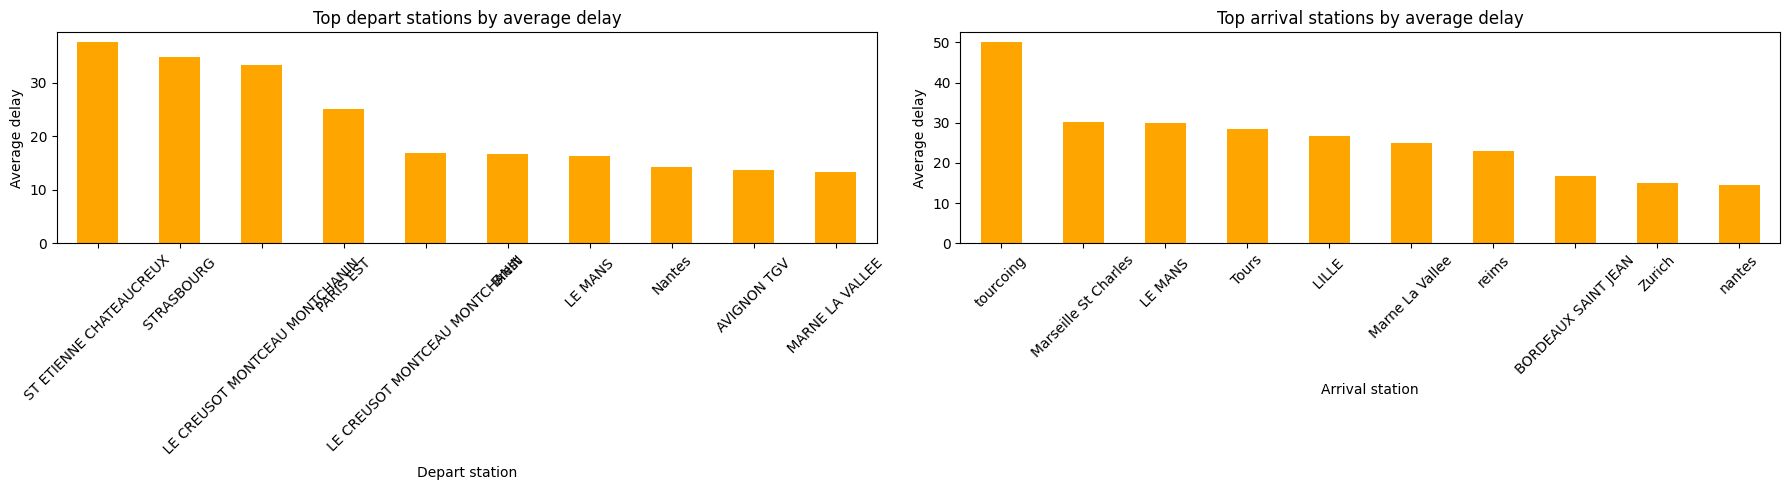

In [346]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

df.groupby("Departure station")[col].mean().sort_values(ascending=False).head(10).plot(
    kind="bar",
    color="orange",
    ax=axes[0]
)

axes[0].set_facecolor("white")
axes[0].set_title("Top depart stations by average delay")
axes[0].set_xlabel("Depart station")
axes[0].set_ylabel("Average delay")
axes[0].tick_params(axis="x", rotation=45)

df.groupby("Arrival station")[col].mean().sort_values(ascending=False).head(10).plot(
    kind="bar",
    color="orange",
    ax=axes[1]
)
axes[1].set_facecolor("white")
axes[1].set_title("Top arrival stations by average delay")
axes[1].set_xlabel("Arrival station")
axes[1].set_ylabel("Average delay")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

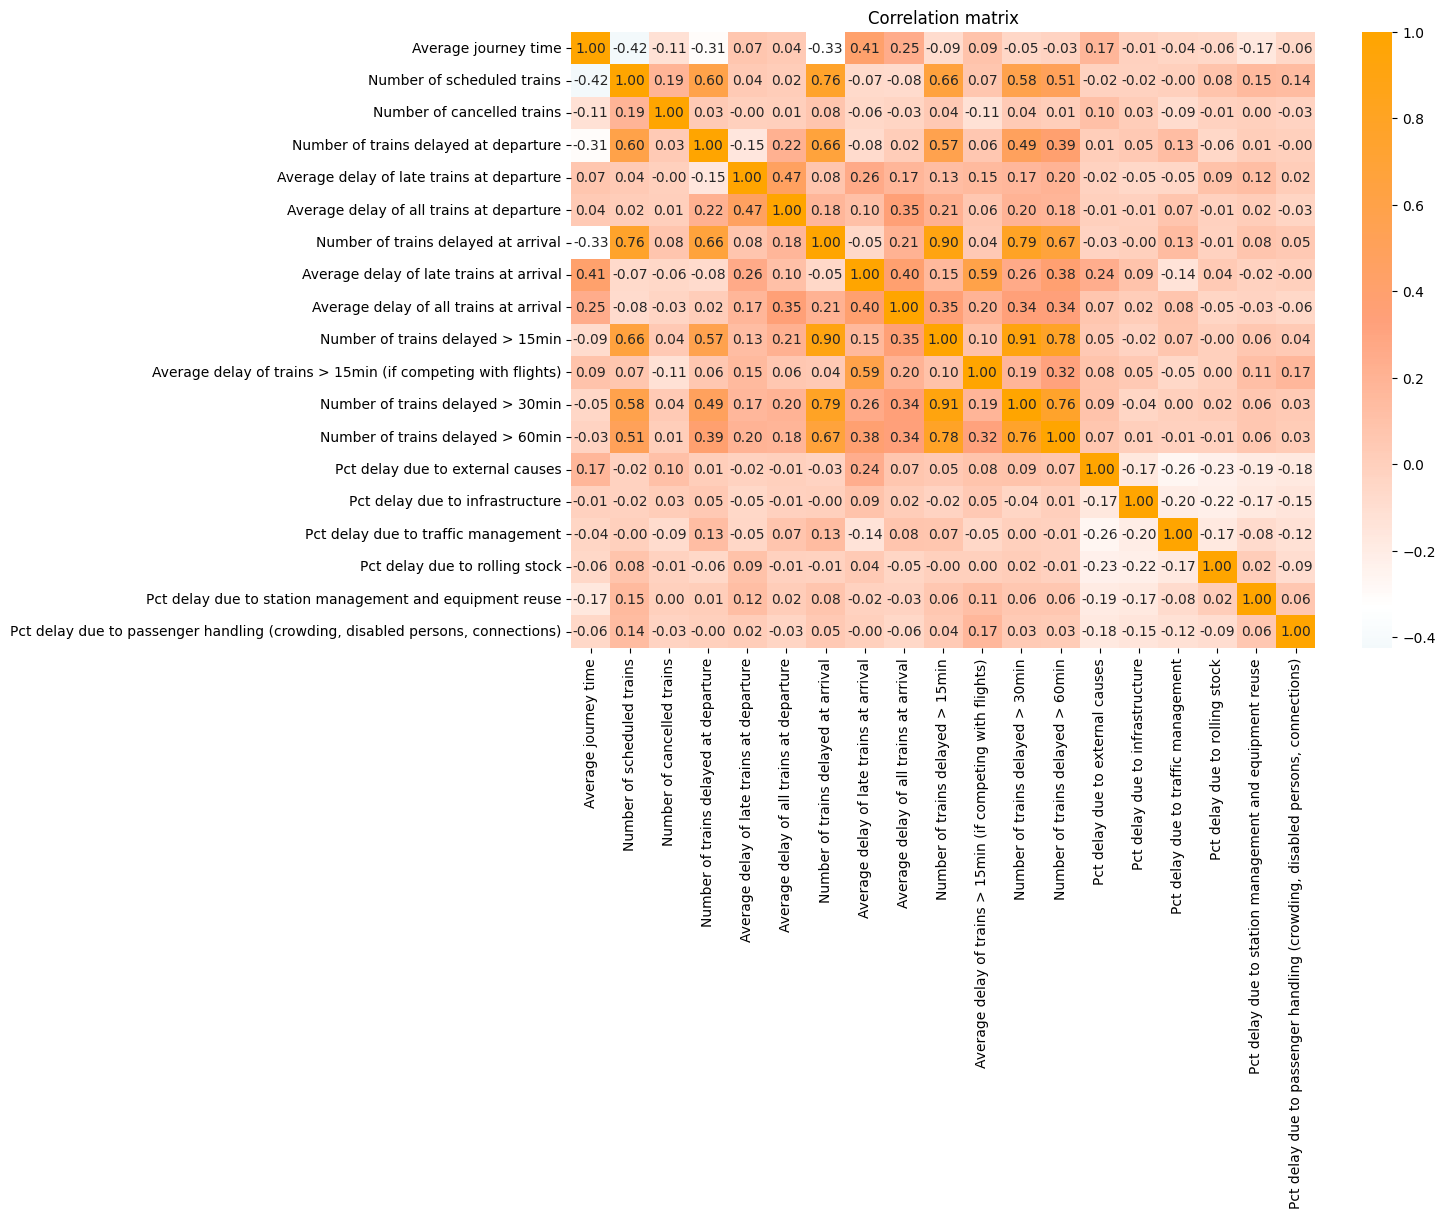

In [347]:
numeric_df = df.select_dtypes(include=["number"])
correlation_matrix = numeric_df.corr()
custom_cmap = LinearSegmentedColormap.from_list(
    "my_colors",
    ["lightblue", "white","lightsalmon", "orange"])

plt.figure(figsize=(12, 8))
plt.gca().set_facecolor("white")
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap=custom_cmap,
    fmt=".2f",
    center=0
)
plt.title("Correlation matrix")
plt.show()